# ANN Lab 9 — Hebbian Learning Rule

| Field | Detail |
|---|---|
| **Name** | Muhammad Taqui |
| **Enrollment No** | 01-136221-021 |
| **Class** | BS AI (6-A) |

## Theory

Hebbian learning is based on the biological principle: *neurons that fire together, wire together*. The weight update rule is:

$$\Delta w = \eta \cdot x \cdot y$$

where $\eta$ is the learning rate, $x$ is the input, and $y$ is the target output.

**Representation:** Bipolar encoding $\{-1, +1\}$ is used instead of binary $\{0, 1\}$ — it allows more symmetric weight updates and is better suited for single-layer perceptrons.

**Limitation:** Hebbian learning cannot solve the XOR problem because XOR is not linearly separable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def hebbian_learning(
    X: np.ndarray,
    y: np.ndarray,
    learning_rate: float = 0.7,
    epochs: int = 1
):
    """Train a single-layer perceptron using the Hebbian learning rule."""
    n_features = X.shape[1]
    weights = np.zeros(n_features)
    bias = 0.0

    for _ in range(epochs):
        for xi, yi in zip(X, y):
            weights += learning_rate * xi * yi
            bias    += yi

    return weights, bias


def predict(X: np.ndarray, weights: np.ndarray, bias: float) -> np.ndarray:
    """Bipolar step activation: +1 if activation > 0, else -1."""
    activation = np.dot(X, weights) + bias
    return np.where(activation > 0, 1, -1)

In [3]:
# Bipolar input table — all four combinations of two boolean inputs
X = np.array([
    [-1, -1],   # False, False
    [-1,  1],   # False, True
    [ 1, -1],   # True,  False
    [ 1,  1],   # True,  True
], dtype=float)

logic_gates = {
    'AND': np.array([-1, -1, -1,  1]),
    'OR':  np.array([-1,  1,  1,  1]),
    'NOR': np.array([ 1, -1, -1, -1]),
}

results = {}
for gate, y in logic_gates.items():
    w, b = hebbian_learning(X, y, learning_rate=0.7, epochs=1)
    preds = predict(X, w, b)
    match = np.array_equal(preds, y)

    results[gate] = {'weights': w, 'bias': b, 'predictions': preds, 'expected': y, 'passed': match}

    status = '✓ Passed' if match else '✗ Failed'
    print(f"{gate} Gate [{status}]")
    print(f"  Weights: {w}  |  Bias: {b}")
    print(f"  Predicted: {preds}")
    print(f"  Expected:  {y}\n")

AND Gate [✓ Passed]
  Weights: [1.4 1.4]  |  Bias: -2.0
  Predicted: [-1 -1 -1  1]
  Expected:  [-1 -1 -1  1]

OR Gate [✓ Passed]
  Weights: [1.4 1.4]  |  Bias: 2.0
  Predicted: [-1  1  1  1]
  Expected:  [-1  1  1  1]

NOR Gate [✓ Passed]
  Weights: [-1.4 -1.4]  |  Bias: -2.0
  Predicted: [ 1 -1 -1 -1]
  Expected:  [ 1 -1 -1 -1]



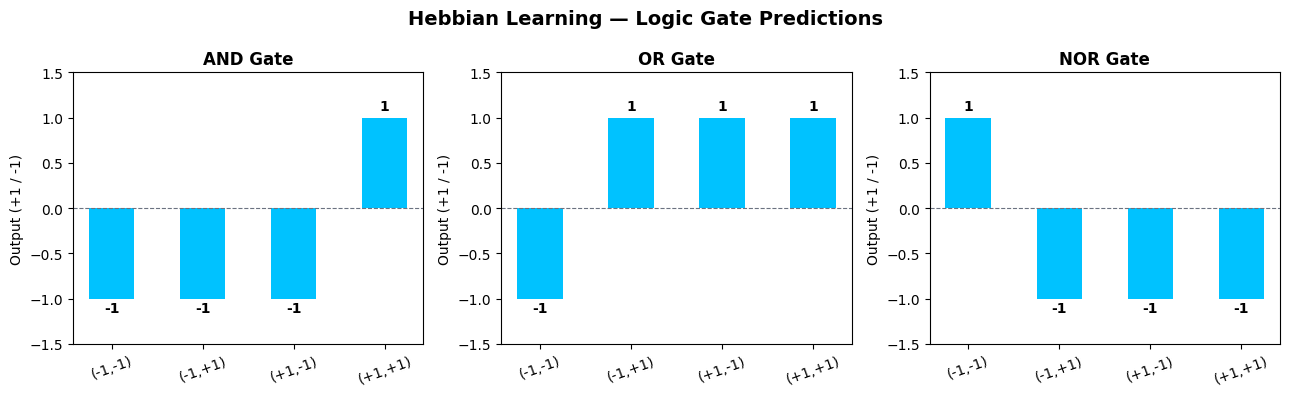

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors_correct = '#00C2FF'
colors_wrong   = '#FF4C4C'

input_labels = ['(-1,-1)', '(-1,+1)', '(+1,-1)', '(+1,+1)']

for ax, (gate, data) in zip(axes, results.items()):
    bar_colors = [
        colors_correct if p == e else colors_wrong
        for p, e in zip(data['predictions'], data['expected'])
    ]
    bars = ax.bar(input_labels, data['predictions'], color=bar_colors, width=0.5)
    ax.set_title(f'{gate} Gate', fontweight='bold', fontsize=12)
    ax.set_ylim(-1.5, 1.5)
    ax.set_ylabel('Output (+1 / -1)')
    ax.axhline(0, color='#6B7280', linewidth=0.8, linestyle='--')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, data['predictions']):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + (0.08 if val > 0 else -0.15),
                str(int(val)), ha='center', fontweight='bold')

plt.suptitle('Hebbian Learning — Logic Gate Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion

Hebbian learning successfully trains AND, OR, and NOR gates in a single epoch using bipolar inputs. The weight updates are proportional to the correlation between input and target — inputs that agree with the desired output reinforce the weight, those that disagree weaken it. XOR remains unsolvable by this architecture because it requires non-linear separation.

In [5]:
# iTaqiZ - PK